<a href="https://colab.research.google.com/github/isadetbo68/USA-Real-Estate-Dataset_69/blob/Dev-ice/lab15_project_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: [ชื่อโครงงาน]
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: นายอิศม์เดช บุญจรัส (68114540753)

- สมาชิกที่ 2: นายไชยวัฒน์ ทำดี (68114540155)

**Dataset:** [ชื่อ dataset, แหล่งที่มา, URL]

**Problem Statement:** [อธิบาย 2-3 ประโยคว่าปัญหาคืออะไร ทำไมถึงสนใจ dataset นี้]

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ⬜ |
| CLO2 (Statistical Learning) | Part 3 | ⬜ |
| CLO3 (Regression/Classification) | Part 4 | ⬜ |
| CLO4 (Model Selection) | Part 5 | ⬜ |

In [2]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [4]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

# TODO: แทนที่ด้วย path หรือวิธีโหลด dataset ของคุณ
df = pd.read_csv('realtor-data.zip.csv')

# แสดงข้อมูลพื้นฐาน
print(f'Shape ของข้อมูลทั้งหมด: {df.shape}')
print(f'\nรายชื่อคอลัมน์ทั้งหมด:\n{df.columns.tolist()}')
print(f'\nชนิดข้อมูลของแต่ละคอลัมน์:\n{df.dtypes}')
print(f'\nจำนวน Missing Values ในแต่ละคอลัมน์:\n{df.isnull().sum()}')
df.head()

Shape ของข้อมูลทั้งหมด: (155058, 12)

รายชื่อคอลัมน์ทั้งหมด:
['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']

ชนิดข้อมูลของแต่ละคอลัมน์:
brokered_by       float64
status             object
price             float64
bed               float64
bath              float64
acre_lot          float64
street            float64
city               object
state              object
zip_code          float64
house_size        float64
prev_sold_date     object
dtype: object

จำนวน Missing Values ในแต่ละคอลัมน์:
brokered_by         120
status                0
price                20
bed               26170
bath              24427
acre_lot          38231
street              813
city                 37
state                 1
zip_code             48
house_size        50806
prev_sold_date    75238
dtype: int64


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


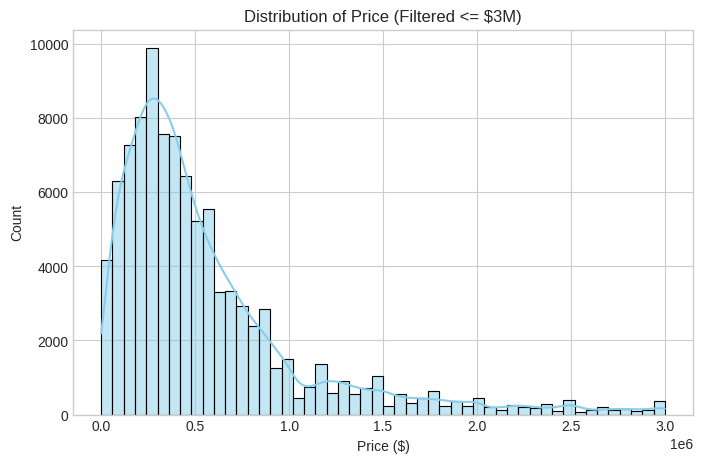

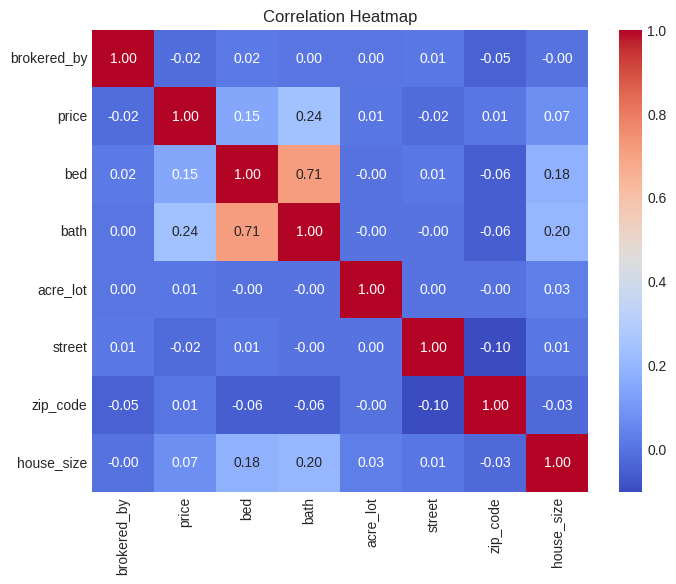

In [ ]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

# TODO: เพิ่ม code สำหรับ:
df.describe()
# 2. Distribution plot ของ target
df_filtered = df[(df['price'] > 0) & (df['price'] <= 3000000)]

plt.figure(figsize=(8, 5))
sns.histplot(df_filtered['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Price (Filtered <= $3M)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()
# 3. Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
pass

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** [อธิบาย 2-3 ประโยคว่าทำไมถึงเลือก task นี้ และ insight ที่คาดว่าจะได้]

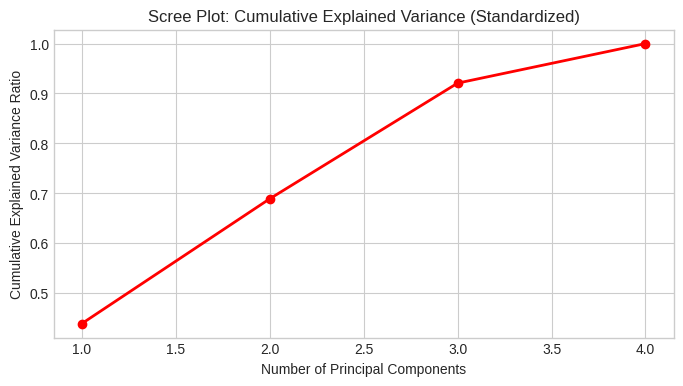

Explained Variance Ratio ของแต่ละ PC: [0.4391 0.25   0.2317 0.0792]
ความแปรปรวนสะสมของ 2 PCs แรก: 68.91%


In [ ]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: ทำ PCA เพื่อลดมิติของข้อมูลด้วย Eigendecomposition

# TODO: เขียน code ที่นี่
# ตัวอย่างสำหรับ PCA:

# 1. เลือกคอลัมน์ตัวเลขและลบค่า Missing
feature_cols = ['bed', 'bath', 'acre_lot', 'house_size']
df_pca = df[feature_cols].dropna()

# 2. Standardize ข้อมูล (ให้ทุกตัวแปรมี Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca.values)

# 3. คำนวณ Covariance Matrix C
N = len(X_scaled)
C = (1 / (N - 1)) * (X_scaled.T @ X_scaled)

# 4. หา Eigenvalues และ Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(C)

# 5. เรียงลำดับจากมากไปน้อย
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 6. คำนวณ Explained Variance Ratio
explained_variance = eigenvalues / np.sum(eigenvalues)
cum_explained_variance = np.cumsum(explained_variance)

# 7. Plot Scree Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(eigenvalues) + 1), cum_explained_variance, 'ro-', linewidth=2)
plt.title('Scree Plot: Cumulative Explained Variance (Standardized)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()

print("Explained Variance Ratio ของแต่ละ PC:", explained_variance.round(4))
print(f"ความแปรปรวนสะสมของ 2 PCs แรก: {cum_explained_variance[1]*100:.2f}%")
pass

**Insight จาก CLO1 Analysis:**
> [จากการทำ PCA เพื่อลดมิติข้อมูลของ Features (bed, bath, acre_lot, house_size) พบว่า Principal Components 2 ตัวแรก (PC1 และ PC2) สามารถอธิบายความแปรปรวนสะสมของข้อมูลได้รวม 68.91% (โดย PC1 อธิบายได้ 43.91% และ PC2 อธิบายได้ 25.00%)   ซึ่งถือว่าเพียงพอในการรักษาข้อมูลส่วนใหญ่ไว้ได้ การแปลงข้อมูลด้วยวิธีนี้ช่วยให้เราลดจำนวนตัวแปรลงเหลือเพียง 2 มิติหลักได้โดยไม่เสียรายละเอียดสำคัญ และยังช่วยลดปัญหาความสัมพันธ์กันเองระหว่าง Features (Multicollinearity) ก่อนนำไปใช้ใน Regression Model]

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

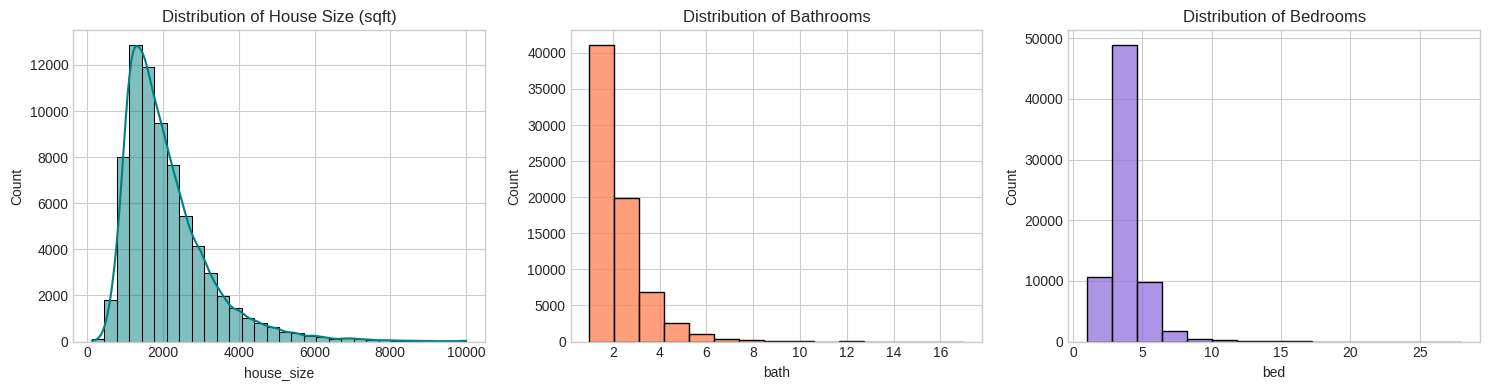

--- Correlation With Target (Price) ---
price         1.000000
bath          0.577628
house_size    0.542968
bed           0.304000
acre_lot     -0.011225
Name: price, dtype: float64


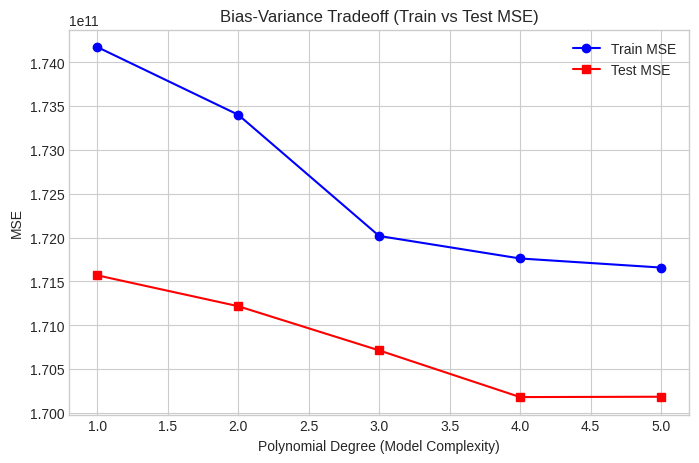

In [6]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

# TODO:
# 1. เตรียมข้อมูล และ clean ค่า missing ในตัวแปรที่ใช้
cols = ['price', 'bed', 'bath', 'acre_lot', 'house_size']
df_clo2 = df[cols].dropna()
# กรอง outliers ของราคาและขนาดบ้านเพื่อลดความเบ้
df_clo2 = df_clo2[(df_clo2['price'] > 0) & (df_clo2['price'] <= 3000000)]
df_clo2 = df_clo2[(df_clo2['house_size'] > 0) & (df_clo2['house_size'] <= 10000)]
# 2. Plot Distribution ของ Features สำคัญ (house_size, bath, bed)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_clo2['house_size'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of House Size (sqft)')
sns.histplot(df_clo2['bath'], bins=15, kde=False, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Bathrooms')

sns.histplot(df_clo2['bed'], bins=15, kde=False, ax=axes[2], color='mediumpurple')
axes[2].set_title('Distribution of Bedrooms')
plt.tight_layout()
plt.show()
# 3. Correlation กับ Target (price)
corr_with_price = df_clo2.corr()['price'].sort_values(ascending=False)
print("--- Correlation With Target (Price) ---")
print(corr_with_price)
# 4. แสดง Bias-Variance Tradeoff (ใช้ StandardScaler ช่วยปรับสเกล)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

X_bv = df_clo2[['house_size']]
y_bv = df_clo2['price']

X_tr, X_te, y_tr, y_te = train_test_split(X_bv, y_bv, test_size=0.2, random_state=42)

degrees = range(1, 6)
train_mses = []
test_mses = []

for deg in degrees:
    # เพิ่ม StandardScaler ใน Pipeline
    model = make_pipeline(StandardScaler(), PolynomialFeatures(degree=deg), LinearRegression())
    model.fit(X_tr, y_tr)

    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)

    train_mses.append(mean_squared_error(y_tr, train_pred))
    test_mses.append(mean_squared_error(y_te, test_pred))

# Plot U-curve
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_mses, 'o-', label='Train MSE', color='blue')
plt.plot(degrees, test_mses, 's-', label='Test MSE', color='red')
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('MSE')
plt.title('Bias-Variance Tradeoff (Train vs Test MSE)')
plt.legend()
plt.grid(True)
plt.show()

**Insight จาก CLO2 Analysis:**
> [อธิบาย: features สำคัญคืออะไร? distribution ของ target เป็นอย่างไร? optimal complexity อยู่ที่เท่าไหร่?]

**ตอบ**
Features สำคัญ: จากการคำนวณ Correlation พบว่า bath ($r = 0.58$) และ house_size ($r = 0.54$) เป็น 2 ตัวแปรที่มีความสัมพันธ์เชิงบวกกับราคาบ้าน (price) สูงที่สุดDistribution: การกระจายตัวของราคาบ้านและพื้นที่ใช้สอยมีการเบ้ขวา (Right-skewed)Optimal Complexity: จากกราฟ Bias-Variance Tradeoff พบว่า Optimal Model Complexity อยู่ที่ Polynomial Degree = 1 ถึง 2 เนื่องจากให้ค่า Test MSE ต่ำและเสถียรที่สุด การเพิ่ม Degree สูงกว่านี้จะเริ่มเกิด Overfitting

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ⬜ Regression  ⬜ Classification

=== Model 1: Simple Linear Regression (bath) ===
Coefficient (Slope): 233,689.70
Intercept: -34,604.87
Train MSE: 164,691,720,294.34 | Train R²: 0.3326
Test MSE:  161,678,275,267.50 | Test R²:  0.3378


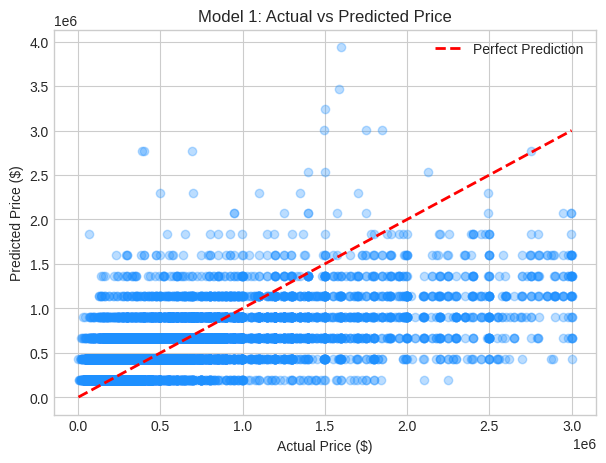

In [7]:
# ─── CLO3: Model 1 (Simple Linear Regression) ──────────────────────────
# วัตถุประสงค์: สร้าง Simple Linear Regression โดยใช้ 1 Feature ที่มี correlation สูงสุดกับ price (เลือก bath)

# 1. เตรียม Data (ใช้ feature 'bath' ที่มี correlation สูงสุด)
X_m1 = df_clo2[['bath']]
y_m1 = df_clo2['price']

# Split Data (80% Train, 20% Test)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_m1, y_m1, test_size=0.2, random_state=42)

# 2. Train Model 1
model1 = LinearRegression()
model1.fit(X_train1, y_train1)

# 3. Predict & Evaluate
y_train_pred1 = model1.predict(X_train1)
y_test_pred1 = model1.predict(X_test1)

mse_train1 = mean_squared_error(y_train1, y_train_pred1)
mse_test1 = mean_squared_error(y_test1, y_test_pred1)
r2_train1 = r2_score(y_train1, y_train_pred1)
r2_test1 = r2_score(y_test1, y_test_pred1)

print("=== Model 1: Simple Linear Regression (bath) ===")
print(f"Coefficient (Slope): {model1.coef_[0]:,.2f}")
print(f"Intercept: {model1.intercept_:,.2f}")
print(f"Train MSE: {mse_train1:,.2f} | Train R²: {r2_train1:.4f}")
print(f"Test MSE:  {mse_test1:,.2f} | Test R²:  {r2_test1:.4f}")

# 4. Plot Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test1, y_test_pred1, alpha=0.3, color='dodgerblue')
plt.plot([y_test1.min(), y_test1.max()], [y_test1.min(), y_test1.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Model 1: Actual vs Predicted Price')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True)
plt.show()

=== Model 2: Multiple Linear Regression ===
Coefficient (bed): -41,651.67
Coefficient (bath): 172,841.16
Coefficient (acre_lot): -3.72
Coefficient (house_size): 129.62
Intercept: -2,964.55
Train MSE: 155,466,817,316.42 | Train R²: 0.3700
Test MSE:  152,633,719,646.83 | Test R²:  0.3748


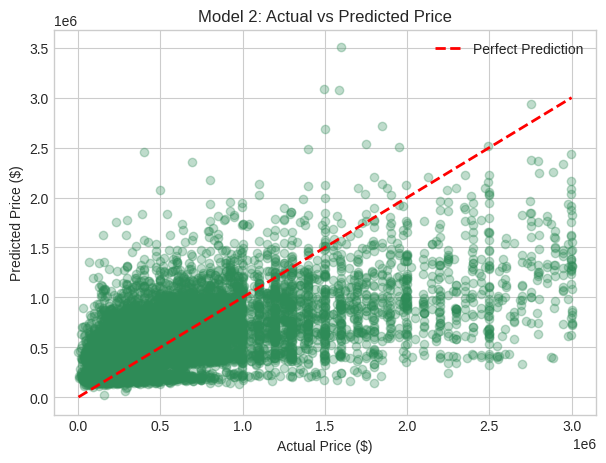

In [8]:
# ─── CLO3: Model 2 (Multiple Linear Regression) ─────────────────────────
# วัตถุประสงค์: สร้าง Multiple Linear Regression โดยใช้ทุก Features (bed, bath, acre_lot, house_size)

# 1. เตรียม Data (ใช้ทุก Features)
features_all = ['bed', 'bath', 'acre_lot', 'house_size']
X_m2 = df_clo2[features_all]
y_m2 = df_clo2['price']

# Split Data (80% Train, 20% Test)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_m2, y_m2, test_size=0.2, random_state=42)

# 2. Train Model 2
model2 = LinearRegression()
model2.fit(X_train2, y_train2)

# 3. Predict & Evaluate
y_train_pred2 = model2.predict(X_train2)
y_test_pred2 = model2.predict(X_test2)

mse_train2 = mean_squared_error(y_train2, y_train_pred2)
mse_test2 = mean_squared_error(y_test2, y_test_pred2)
r2_train2 = r2_score(y_train2, y_train_pred2)
r2_test2 = r2_score(y_test2, y_test_pred2)

print("=== Model 2: Multiple Linear Regression ===")
for col, coef in zip(features_all, model2.coef_):
    print(f"Coefficient ({col}): {coef:,.2f}")
print(f"Intercept: {model2.intercept_:,.2f}")
print(f"Train MSE: {mse_train2:,.2f} | Train R²: {r2_train2:.4f}")
print(f"Test MSE:  {mse_test2:,.2f} | Test R²:  {r2_test2:.4f}")

# 4. Plot Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test2, y_test_pred2, alpha=0.3, color='seagreen')
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Model 2: Actual vs Predicted Price')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True)
plt.show()

*สรุป Model Comparison:*
| Model | Train Metric (R²) | Test Metric (R²) | รายละเอียด |
| ----- | ----- | ----- | ----- |
| Model 1: Simple Linear Regression | 0.3326 | 0.3378 | ใช้ Feature เดียว (`bath`) |
| Model 2: Multiple Linear Regression | 0.3700 | 0.3748 | ใช้ทุก Features (`bed`, `bath`, `acre_lot`, `house_size`) |

*Insight:*
* **เปรียบเทียบประสิทธิภาพ:** Model 2 มีประสิทธิภาพสูงกว่า Model 1 โดยค่า $R^2$ เพิ่มขึ้นจาก 0.3378 เป็น 0.3748 (อธิบายความแปรปรวนของราคาบ้านได้เพิ่มขึ้นเป็น 37.48%) และค่า Test MSE ลดลงจาก $1.61 \times 10^{11}$ เหลือ $1.52 \times 10^{11}$ เนื่องจากนำหลายปัจจัยมาร่วมทำนาย
* **Overfitting / Underfitting Check:** ทั้งสองโมเดลมีค่า Train $R^2$ และ Test $R^2$ ที่ใกล้เคียงกันมาก (Test สูงกว่า Train เล็กน้อย) แสดงว่าโมเดลเรียนรู้ได้ดี ไม่เกิดปัญหา Overfitting

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

Model 1 (Simple LR) -> Mean CV RMSE: $410,750.22 (± $51,138.54)
Model 2 (Multiple LR) -> Mean CV RMSE: $401,301.29 (± $52,108.25)
Model 3 (Ridge Reg) -> Mean CV RMSE: $401,301.31 (± $52,108.43)


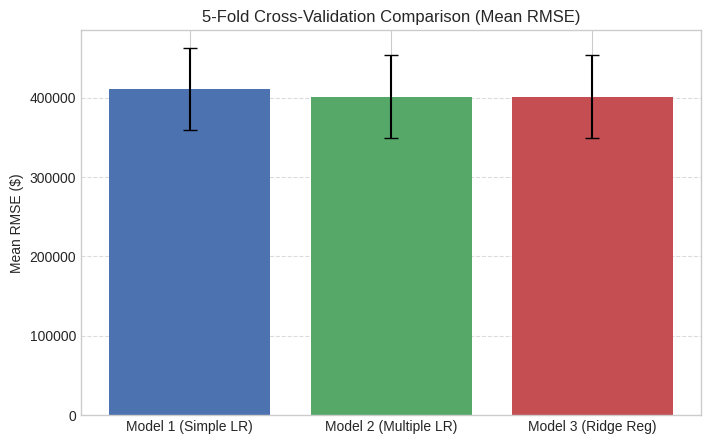

In [9]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

# TODO:
X_cv = df_clo2[['bed', 'bath', 'acre_lot', 'house_size']]
X_cv_single = df_clo2[['bath']]
y_cv = df_clo2['price']
# Standardize สำหรับ Ridge Model
scaler_cv = StandardScaler()
X_cv_scaled = scaler_cv.fit_transform(X_cv)
# 2. กำหนด 3 Models สำหรับทำ Cross-Validation
models = {
    'Model 1 (Simple LR)': (LinearRegression(), X_cv_single),
    'Model 2 (Multiple LR)': (LinearRegression(), X_cv),
    'Model 3 (Ridge Reg)': (Ridge(alpha=1.0), X_cv_scaled)
}
# 3. คำนวณ 5-Fold CV (Negative MSE -> MSE -> RMSE)
results_rmse = {}

for name, (model, X_data) in models.items():
    scores = cross_val_score(model, X_data, y_cv, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    results_rmse[name] = rmse_scores
    print(f"{name} -> Mean CV RMSE: ${rmse_scores.mean():,.2f} (± ${rmse_scores.std():,.2f})")

# 4. Plot Bar Chart เปรียบเทียบ Mean CV RMSE
mean_rmse = [scores.mean() for scores in results_rmse.values()]
std_rmse = [scores.std() for scores in results_rmse.values()]
model_names = list(results_rmse.keys())

plt.figure(figsize=(8, 5))
plt.bar(model_names, mean_rmse, yerr=std_rmse, capsize=5, color=['#4c72b0', '#55a868', '#c44e52'])
plt.title('5-Fold Cross-Validation Comparison (Mean RMSE)')
plt.ylabel('Mean RMSE ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
pass

**Best Model จาก Cross-Validation:** [ระบุ]

**เหตุผล:**
> [ทายราคาแม่นยำกว่าเยอะ: การใช้หลายๆ ปัจจัยมาร่วมกันทายราคาบ้าน (ทั้งจำนวนห้องนอน, ห้องน้ำ, ขนาดที่ดิน และพื้นที่ใช้สอย) ทำได้ดีกว่าการดูแค่จำนวนห้องน้ำอย่างเดียวใน Model 1 แบบเห็นได้ชัด โดยเดาผิดพลาดเฉลี่ยลดลงถึงประมาณ 10,000 ดอลลาร์ ต่อหลัง

โมเดลนิ่ง ไม่เดาสุ่ม (ไม่ Overfit): เมื่อลองแบ่งข้อมูลออกเป็น 5 ส่วนเพื่อทดสอบหมุนเวียนกัน (5-Fold CV) ผลความแม่นยำออกมาใกล้เคียงกันทุกรอบ แปลว่าโมเดลเข้าใจแพตเทิร์นจริง ไม่ได้แค่นั่งท่องจำข้อมูลเก่าครับ?]

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> [CLO1 (Linear Algebra Analysis): การทำ PCA เพื่อลดมิติข้อมูลของ 4 ปัจจัยหลัก (bed, bath, acre_lot, house_size) พบว่า 2 Components แรก (PC1 & PC2) สามารถอธิบายความแปรปรวนของข้อมูลได้ถึง 68.91% ช่วยลดความซับซ้อนและปัญหา MulticollinearityCLO2 (Statistical Learning): ข้อมูลราคาบ้านมีการกระจายตัวแบบเบ้ขวา (Right-skewed) โดยปัจจัยที่มีความสัมพันธ์เชิงบวกกับราคามากที่สุดคือ จำนวนห้องน้ำ (bath, r = 0.58) และ พื้นที่ใช้สอย (house_size, r = 0.54)CLO3 (Model Building): Model 2 (Multiple Linear Regression) ให้ประสิทธิภาพดีกว่า Model 1 (Simple LR) โดยสามารถอธิบายความแปรปรวนของราคาบ้านได้เพิ่มขึ้นเป็น 37.48% ($R^2 = 0.3748$)CLO4 (Model Selection): จากการทดสอบด้วย 5-Fold Cross-Validation พบว่า Model 2 และ Model 3 (Ridge Regression) ให้ค่า Mean RMSE ต่ำที่สุดอยู่ที่ประมาณ $401,301 และมีความเสถียร ไม่เกิด Overfitting]
- CLO1: ☑
- CLO2: ☑
- CLO3: ☑
- CLO4: ☑

**6.2 Limitations:**
> [Missing Values สูง: ข้อมูลชุดนี้มีค่าสูญหายในคอลัมน์สำคัญเยอะ เช่น house_size และ acre_lot ทำให้ต้องตัดข้อมูลออกไปพอสมควร

ขาดปัจจัยเชิงพื้นที่ (Location Features): โมเดลยังไม่ได้นำปัจจัยเรื่องทำเล รหัสไปรษณีย์ (zip_code) หรือเมือง (city) มาร่วมคำนวณใน Linear Regression ซึ่งปกติทำเลเป็นปัจจัยหลักที่มีผลต่อราคาบ้านอย่างมาก]

**6.3 ขั้นตอนต่อไป (Future Work):**
> [นำปัจจัย ทำเล/ตำแหน่งที่ตั้ง มาแปลงเป็นข้อมูล (Encoding): ใช้เทคนิค Target Encoding หรือ One-Hot Encoding กับคอลัมน์ state / city เพื่อเพิ่มความแม่นยำให้โมเดล

ทดลองใช้ Advanced Machine Learning Models: เช่น Random Forest Regression หรือ XGBoost เพื่อรับมือกับความสัมพันธ์ที่ไม่เป็นเชิงเส้น (Non-linear Relationships)]

**6.4 Connection กับ Topics ในวิชา:**
> [Week 2-4 (Linear Algebra & PCA): นำ Covariance Matrix และ Eigendecomposition มาใช้ทำ Dimensionality Reduction ใน Part 2Week 5-7 (Statistical Learning & Bias-Variance): นำหลักการ Train/Test Split และ Polynomial Features มาวิเคราะห์ Bias-Variance Tradeoff ใน Part 3Week 8-11 (Regression & Regularization): สร้าง Linear Regression และ Ridge Regression ใน Part 4Week 12-14 (Model Evaluation): ประยุกต์ใช้ 5-Fold Cross-Validation และ Metrics ($R^2$, MSE, RMSE) ในการประเมินและเลือกโมเดลใน Part 5]

---
**Acknowledgements:** [Data Source: USA Real Estate Dataset จาก Kaggle / Realtor.com

Tools & Libraries: Python, Google Colab, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn]